# Predicting Charlotte crash hotspots

**Research question:** Can past reported crashes help predict which 500-meter areas of Charlotte will have more crashes next month? A smaller extension asks whether separate morning and afternoon forecasts identify different hotspots.

This is a **regression** problem. The main target is the number of reported crashes in one map cell during one calendar month. The model ranks areas with higher predicted counts. It does not predict the location or time of an individual crash. The Federal Highway Administration describes using crash history to identify areas for further safety investigation ([FHWA, n.d.-b](https://highways.dot.gov/safety/data-analysis-tools/systemic/screening-your-network-improve-roadway-safety-performance)).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats

## Data and first checks

The crash records come from the City of Charlotte's [Crashes map layer](https://gis.charlottenc.gov/arcgis/rest/services/CDOT/TCLS_Crashes/MapServer/0). The original CSV has 540,865 rows and includes a crash ID, date, time, coordinates, and descriptive fields. The notebook uses crashes from 2018 through 2024. The local file paths in the next cells point to the author's computer, so another reader will need to put the two CSV files where the notebook can find them.

In [3]:
df = pd.read_csv(r'C:\Users\kyleh\OneDrive\Desktop\Project_2_DTSC\Crashes.csv')

In [4]:

display(df.describe())
display(df.head())

,X,Y,OBJECTID,CRSH_ID,DATE_VAL_YEAR,DATE_VAL_MONTH,DATE_VAL_DAY,DAY_OF_WEEK,MILT_TIME,CASE_NUM,CRSH_TYPE_CD,CRSH_LEVL,LATITUDE,LONGITUDE
count,5.408650e+05,5.408650e+05,540865.00000,5.408650e+05,540865.000000,540865.000000,540865.000000,540865.000000,540865.000000,5.408650e+05,540865.000000,540581.000000,540755.000000,540755.000000
mean,2.006691e+06,1.102772e+06,270433.00000,9.657934e+05,2018.987233,6.517710,15.663807,4.126767,1374.573444,2.019488e+13,23.544849,4.680227,35.221301,-77.875886
std,4.049145e+06,4.114350e+06,156134.42101,2.584611e+05,4.383339,3.429636,8.752797,1.906559,526.757337,2.747909e+12,12.011547,0.605795,0.193836,21.620978
min,-5.789194e+07,-1.111645e+06,1.00000,4.468660e+05,2010.000000,1.000000,1.000000,1.000000,0.000000,7.337250e+05,0.000000,1.000000,-33.852818,-118.255709
25%,1.440400e+06,5.230997e+05,135217.00000,7.513380e+05,2016.000000,4.000000,8.000000,3.000000,1018.000000,2.016013e+13,21.000000,4.000000,35.168582,-80.873980
50%,1.453015e+06,5.408631e+05,270433.00000,9.713690e+05,2019.000000,7.000000,16.000000,4.000000,1436.000000,2.019091e+13,21.000000,5.000000,35.220253,-80.831320
75%,1.471457e+06,5.603617e+05,405649.00000,1.206984e+06,2023.000000,10.000000,23.000000,6.000000,1747.000000,2.023040e+13,28.000000,5.000000,35.269418,-80.769570
max,3.288898e+07,3.127890e+07,540865.00000,2.244290e+06,2026.000000,12.000000,31.000000,7.000000,2359.000000,2.019071e+15,99.000000,6.000000,80.514600,151.090471


,X,Y,OBJECTID,CRSH_ID,DATE_VAL,DATE_VAL_YEAR,DATE_VAL_MONTH,DATE_VAL_MONTH_DESC,DATE_VAL_DAY,DAY_OF_WEEK,DAY_OF_WEEK_DESC,MILT_TIME,CASE_NUM,CRSH_TYPE_CD,CRASH_TYPE,CRSH_LEVL,CRSH_LEVL_DESC,LATITUDE,LONGITUDE
0,1.421290e+06,510847.640899,1,1248943,2024/03/14 00:47:00+00,2024,3,March,13,4,Wednesday,2047,20240313204702,21,Rear end; slow or stop,5.0,Property Damage,35.138144,-80.935869
1,1.444834e+06,479307.310607,2,1248944,2024/03/14 00:47:00+00,2024,3,March,13,4,Wednesday,2047,20240313204703,20,Parked motor vehicle,5.0,Property Damage,35.052731,-80.855160
2,1.439186e+06,510542.950892,3,1248945,2024/03/14 00:53:00+00,2024,3,March,13,4,Wednesday,2053,20240313205300,31,Backing up,5.0,Property Damage,35.138251,-80.875999
3,1.456028e+06,484471.706118,4,1248946,2024/03/14 01:04:00+00,2024,3,March,13,4,Wednesday,2104,20240313210401,21,Rear end; slow or stop,5.0,Property Damage,35.067488,-80.818076
4,1.488704e+06,530578.149994,5,1248947,2024/03/14 01:25:00+00,2024,3,March,13,4,Wednesday,2125,20240313212501,24,Left turn; different roadways,5.0,Property Damage,35.195751,-80.711547


In [5]:
print("Rows and columns:", df.shape)
print("Years:", df["DATE_VAL_YEAR"].min(), "to", df["DATE_VAL_YEAR"].max())
print("Duplicate crash IDs:", df["CRSH_ID"].duplicated().sum())

display(df[["DATE_VAL", "LATITUDE", "LONGITUDE"]].isna().sum())
display(df.groupby("DATE_VAL_YEAR").size().rename("crashes"))

Rows and columns: (540865, 19)
Years: 2010 to 2026
Duplicate crash IDs: 0


DATE_VAL       0
LATITUDE     110
LONGITUDE    110
dtype: int64

DATE_VAL_YEAR
2010    15631
2011    15399
2012    14722
2013    23211
2014    29323
2015    34109
2016    37398
2017    36942
2018    37789
2019    38376
2020    29345
2021    38560
2022    44268
2023    44472
2024    43384
2025    33425
2026    24511
Name: crashes, dtype: int64

### Cleaning the crash locations

I retain records in the selected years with coordinates in a plausible Charlotte-area range. This removes missing or clearly misplaced coordinates before mapping. The resulting crash table contains 276,118 records. This coordinate check is a practical geographic filter, not a formal Charlotte city-boundary test.

In [6]:
crashes = df[df["DATE_VAL_YEAR"].between(2018, 2024)].copy()

valid_location = (
    crashes["LATITUDE"].between(34.8, 35.6)
    & crashes["LONGITUDE"].between(-81.3, -80.4)
)

print("Rows before location filter:", len(crashes))
crashes = crashes.loc[valid_location].copy()
print("Rows after location filter:", len(crashes))

Rows before location filter: 276194
Rows after location filter: 276118


In [7]:
display(df[["LATITUDE", "LONGITUDE"]].head())
print(df[["LATITUDE", "LONGITUDE"]].isna().sum())

,LATITUDE,LONGITUDE
0,35.138144,-80.935869
1,35.052731,-80.855160
2,35.138251,-80.875999
3,35.067488,-80.818076
4,35.195751,-80.711547


LATITUDE     110
LONGITUDE    110
dtype: int64


## Exploring when and where crashes were reported

The next charts show yearly and monthly totals, a rough location map, and a day-of-week and hour breakdown. These are **counts of reported crashes**, not crash rates per trip or per mile driven. Busy roads can have high counts simply because more vehicles use them.

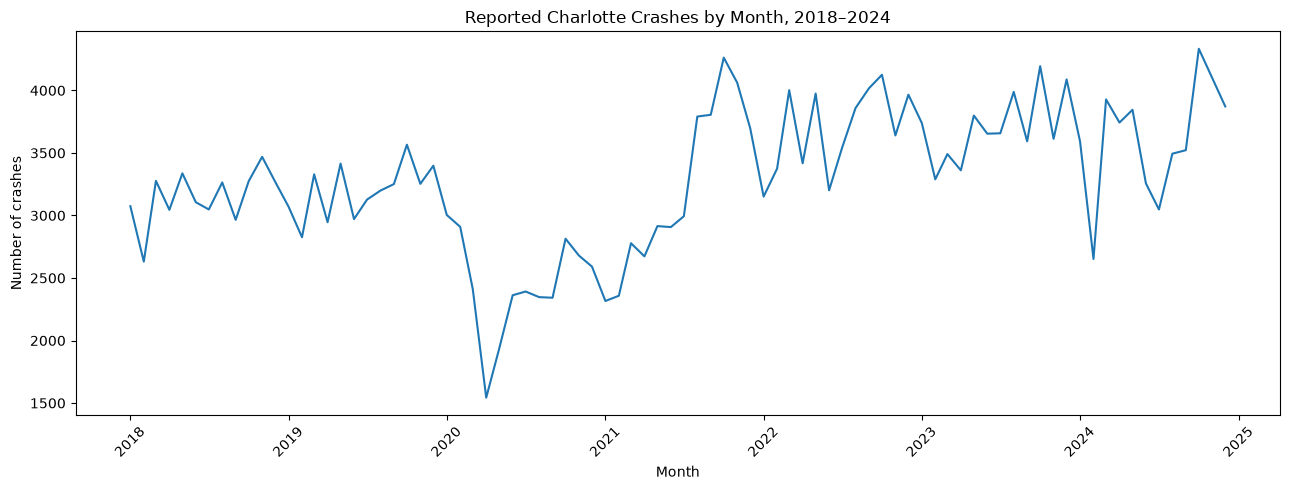

In [8]:
monthly = (
    crashes.groupby(["DATE_VAL_YEAR", "DATE_VAL_MONTH"])
    .size()
    .reset_index(name="crash_count")
)

monthly["month_date"] = pd.to_datetime(
    dict(year=monthly["DATE_VAL_YEAR"], month=monthly["DATE_VAL_MONTH"], day=1)
)

plt.figure(figsize=(13, 5))
sns.lineplot(data=monthly, x="month_date", y="crash_count")
plt.title("Reported Charlotte Crashes by Month, 2018–2024")
plt.xlabel("Month")
plt.ylabel("Number of crashes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

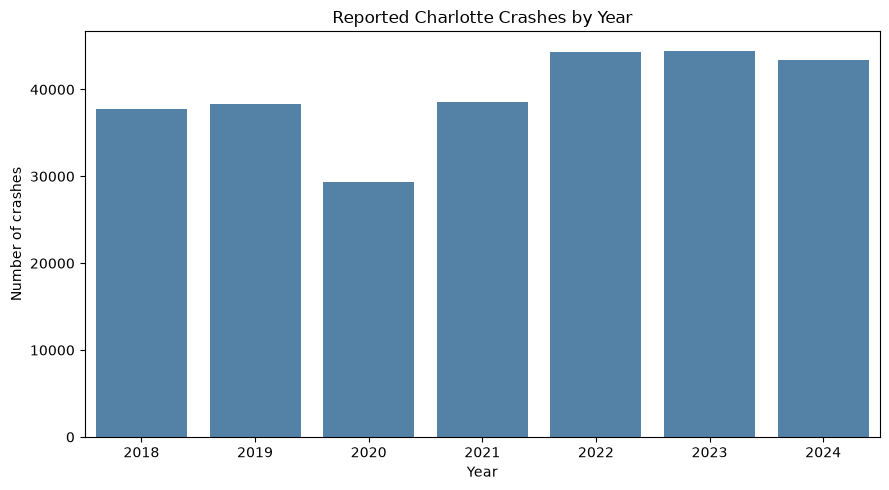

In [9]:
yearly = crashes.groupby("DATE_VAL_YEAR").size()

plt.figure(figsize=(9, 5))
sns.barplot(x=yearly.index, y=yearly.values, color="steelblue")
plt.title("Reported Charlotte Crashes by Year")
plt.xlabel("Year")
plt.ylabel("Number of crashes")
plt.tight_layout()
plt.show()

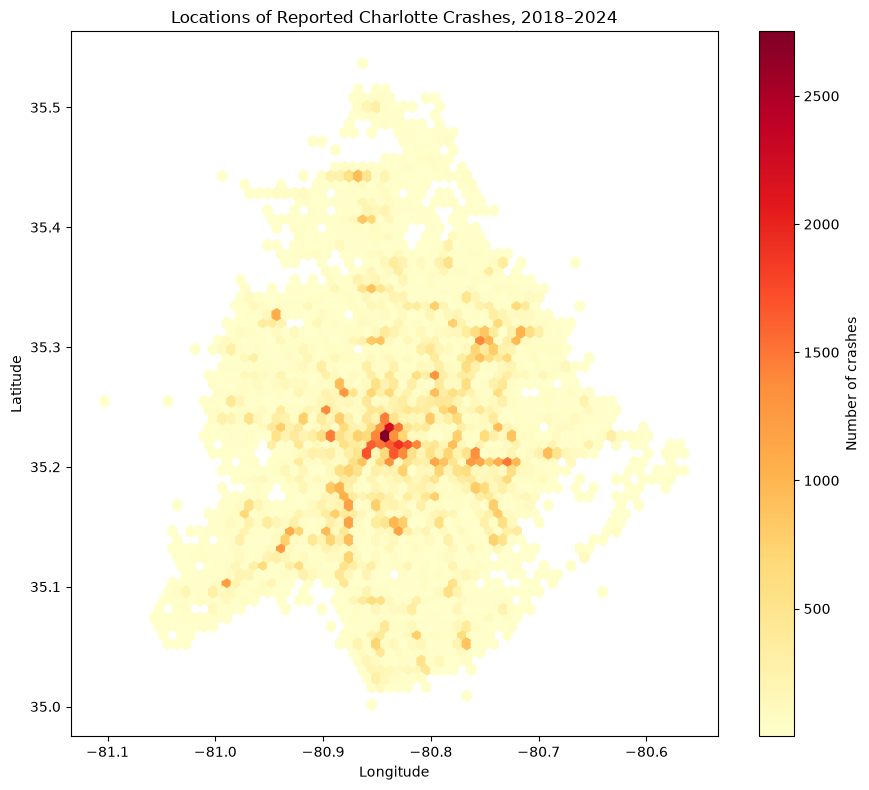

In [10]:
plt.figure(figsize=(9, 8))
plt.hexbin(
    crashes["LONGITUDE"],
    crashes["LATITUDE"],
    gridsize=65,
    cmap="YlOrRd",
    mincnt=1
)
plt.colorbar(label="Number of crashes")
plt.title("Locations of Reported Charlotte Crashes, 2018–2024")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

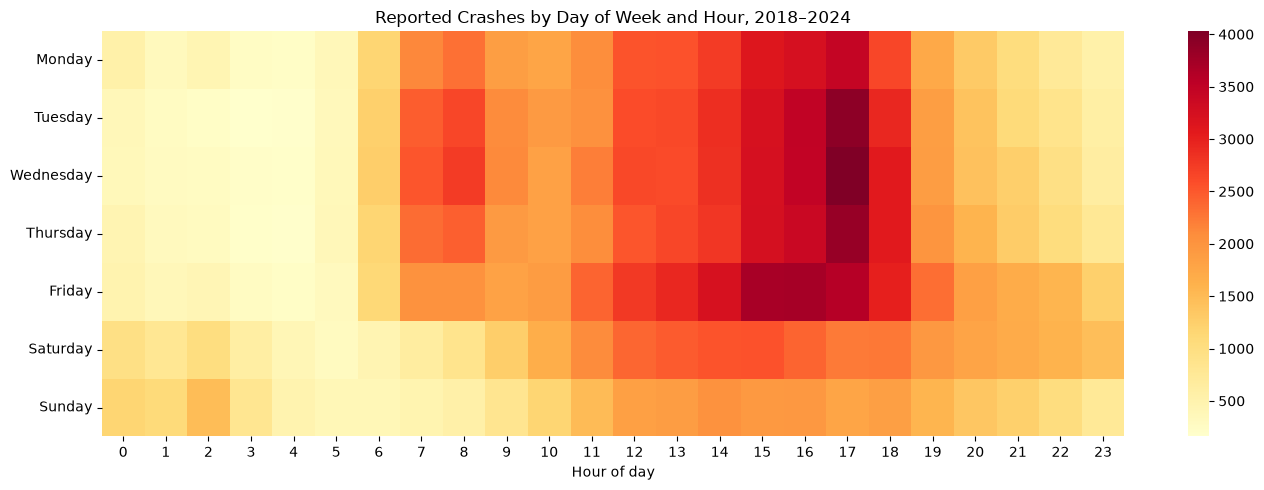

In [11]:
crashes["hour"] = crashes["MILT_TIME"] // 100

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

crashes_by_day_hour = pd.crosstab(
    crashes["DAY_OF_WEEK_DESC"],
    crashes["hour"]
).reindex(day_order)

plt.figure(figsize=(14, 5))
sns.heatmap(crashes_by_day_hour, cmap="YlOrRd")
plt.title("Reported Crashes by Day of Week and Hour, 2018–2024")
plt.xlabel("Hour of day")
plt.ylabel("")
plt.tight_layout()
plt.show()

Reported crashes were most common during weekday afternoons, especially around the evening commute. Friday afternoons had some of the highest counts. This chart shows when crashes were reported across Charlotte, but it does not yet show where those crashes happened.

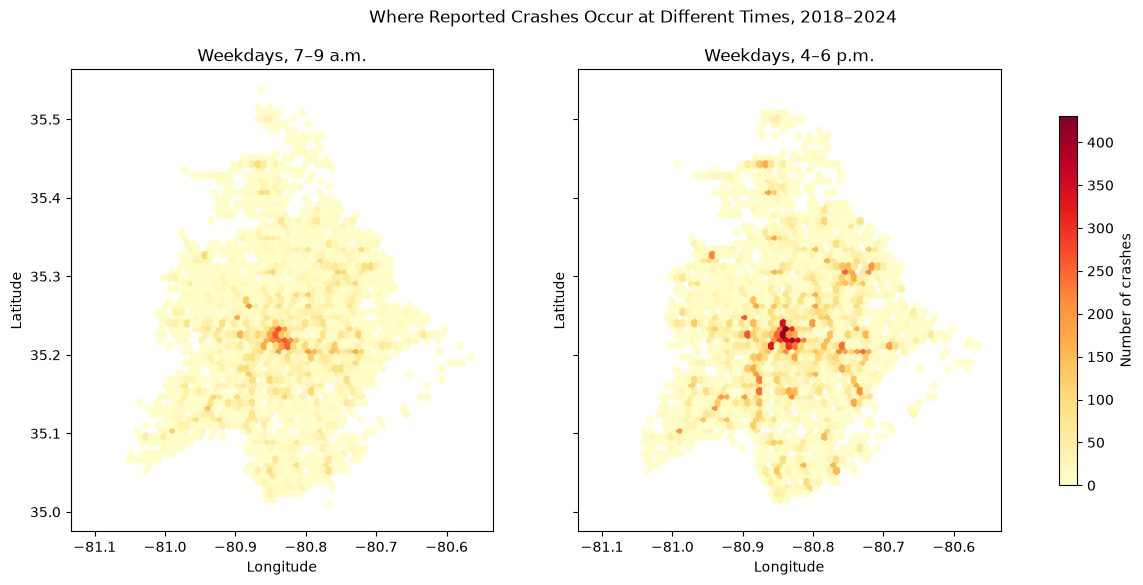

In [12]:
weekdays = crashes["DAY_OF_WEEK_DESC"].isin(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
)

morning = crashes[weekdays & crashes["hour"].between(7, 9)]
afternoon = crashes[weekdays & crashes["hour"].between(16, 18)]

map_extent = (
    crashes["LONGITUDE"].min(), crashes["LONGITUDE"].max(),
    crashes["LATITUDE"].min(), crashes["LATITUDE"].max()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

morning_map = axes[0].hexbin(
    morning["LONGITUDE"], morning["LATITUDE"],
    gridsize=65, extent=map_extent, cmap="YlOrRd", mincnt=1
)
afternoon_map = axes[1].hexbin(
    afternoon["LONGITUDE"], afternoon["LATITUDE"],
    gridsize=65, extent=map_extent, cmap="YlOrRd", mincnt=1
)

# Give both maps the same color scale
color_max = max(morning_map.get_array().max(), afternoon_map.get_array().max())
morning_map.set_clim(0, color_max)
afternoon_map.set_clim(0, color_max)

axes[0].set_title("Weekdays, 7–9 a.m.")
axes[1].set_title("Weekdays, 4–6 p.m.")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(afternoon_map, ax=axes, label="Number of crashes", shrink=0.8)
fig.suptitle("Where Reported Crashes Occur at Different Times, 2018–2024")
plt.show()

### Weather exploration

I matched each crash to its Charlotte local calendar date, then joined daily observations from NOAA's Charlotte Douglas Airport station ([NOAA NCEI, n.d.](https://www.ncei.noaa.gov/cdo-web/datasets/LCD/stations/WBAN%3A13881/detail)). This lets me compare reported crash totals on wet and dry days. The Federal Highway Administration notes that rain and wet pavement can affect driving safety ([FHWA, n.d.-a](https://ops.fhwa.dot.gov/weather/weather_events/rain_flooding.htm)). A daily airport measurement does not tell me the road conditions at every crash location and hour.

Weather here is descriptive. Observed rain for a future month would not be available when making a forecast, so the predictive models below **do not use that future observed weather** as a feature.

In [13]:
weather = pd.read_csv(
    "Charlotte_weather_2018_2024.csv",
    parse_dates=["DATE"]
)

# DATE_VAL is in UTC, so convert it to Charlotte's local date
crashes["local_date"] = (
    pd.to_datetime(crashes["DATE_VAL"], utc=True)
    .dt.tz_convert("America/New_York")
    .dt.tz_localize(None)
    .dt.normalize()
)

crashes_weather = crashes.merge(
    weather,
    left_on="local_date",
    right_on="DATE",
    how="left",
    validate="many_to_one",
    indicator=True
)

print(crashes_weather["_merge"].value_counts())
display(crashes_weather[
    ["local_date", "CRSH_ID", "PRCP", "SNOW", "TMAX", "TMIN"]
].head())

_merge
both          276118
left_only          0
right_only         0
Name: count, dtype: int64


,local_date,CRSH_ID,PRCP,SNOW,TMAX,TMIN
0,2024-03-13,1248943,0.0,0.0,76,43
1,2024-03-13,1248944,0.0,0.0,76,43
2,2024-03-13,1248945,0.0,0.0,76,43
3,2024-03-13,1248946,0.0,0.0,76,43
4,2024-03-13,1248947,0.0,0.0,76,43


In [14]:
weather["year"] = weather["DATE"].dt.year
weather["month"] = weather["DATE"].dt.month
weather["wet_day"] = (weather["PRCP"] > 0).astype(int)

monthly_weather = (
    weather.groupby(["year", "month"])
    .agg(
        wet_days=("wet_day", "sum"),
        total_precip_in=("PRCP", "sum"),
        avg_high_f=("TMAX", "mean"),
        avg_low_f=("TMIN", "mean")
    )
    .reset_index()
)

typical_weather = (
    monthly_weather[monthly_weather["year"] <= 2022]
    .groupby("month")
    .agg(
        typical_wet_days=("wet_days", "mean"),
        typical_precip_in=("total_precip_in", "mean"),
        typical_high_f=("avg_high_f", "mean"),
        typical_low_f=("avg_low_f", "mean")
    )
    .round(1)
)

display(typical_weather)

,typical_wet_days,typical_precip_in,typical_high_f,typical_low_f
month,,,,
1,11.6,4.0,52.7,32.2
2,12.2,4.5,59.4,38.8
3,10.4,4.3,65.2,43.1
4,7.4,4.5,73.5,48.5
5,11.0,3.4,81.6,59.9
6,10.6,3.0,87.9,67.2
7,11.4,4.6,91.5,70.9
8,13.2,4.7,89.4,69.7
9,7.2,4.4,85.1,64.5


,days,avg_crashes,median_crashes
Dry days,1729,107.2,108.0
Wet days,828,109.6,110.0


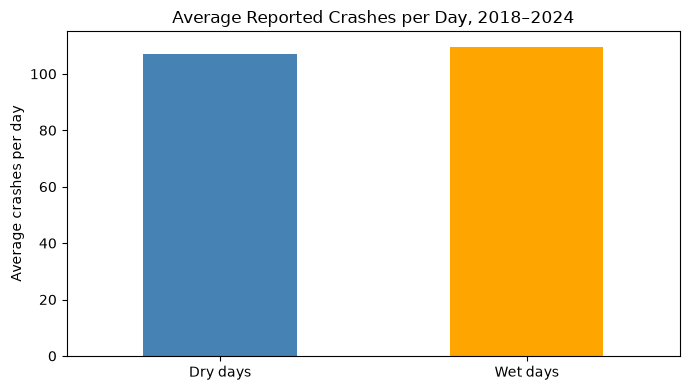

In [15]:
# Count unique crashes on each local date
daily_crashes = (
    crashes_weather.groupby("local_date")["CRSH_ID"]
    .nunique()
    .rename("crash_count")
)

# Start with weather so days with zero reported crashes stay in the data
daily_comparison = weather.join(daily_crashes, on="DATE")
daily_comparison["crash_count"] = (
    daily_comparison["crash_count"].fillna(0).astype(int)
)

wet_dry_summary = (
    daily_comparison.groupby("wet_day")["crash_count"]
    .agg(days="size", avg_crashes="mean", median_crashes="median")
    .round(1)
)

wet_dry_summary.index = ["Dry days", "Wet days"]
display(wet_dry_summary)

wet_dry_summary["avg_crashes"].plot.bar(
    figsize=(7, 4), color=["steelblue", "orange"]
)
plt.title("Average Reported Crashes per Day, 2018–2024")
plt.ylabel("Average crashes per day")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

wet_day,Dry days,Wet days
month,,
1,99.3,104.5
2,101.5,100.7
3,105.5,109.9
4,97.8,101.0
5,105.6,109.7
6,102.7,101.1
7,99.5,102.1
8,109.7,111.3
9,111.8,112.2


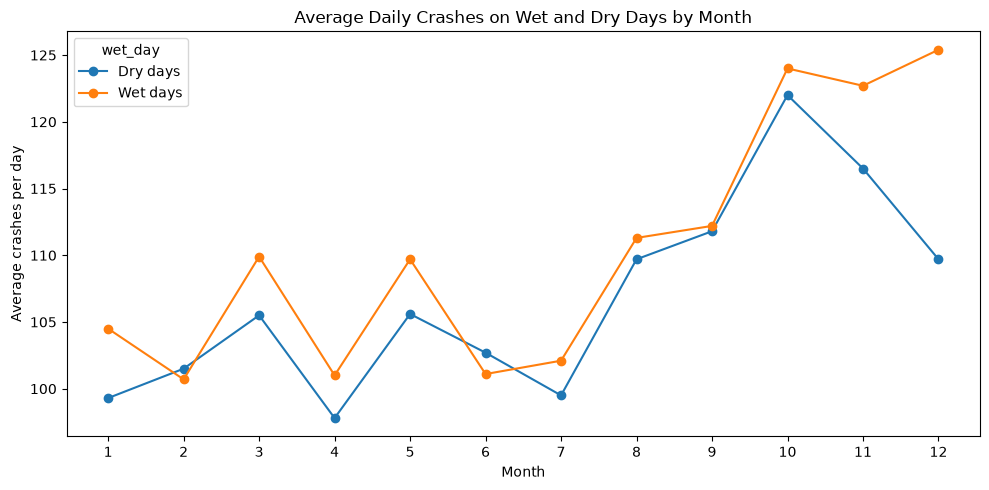

In [16]:
daily_comparison["month"] = daily_comparison["DATE"].dt.month

monthly_wet_dry = (
    daily_comparison
    .groupby(["month", "wet_day"])["crash_count"]
    .mean()
    .unstack()
    .rename(columns={0: "Dry days", 1: "Wet days"})
    .round(1)
)

display(monthly_wet_dry)

monthly_wet_dry.plot(figsize=(10, 5), marker="o")
plt.title("Average Daily Crashes on Wet and Dry Days by Month")
plt.xlabel("Month")
plt.ylabel("Average crashes per day")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

,DATE,day_of_week,PRCP,TMAX,TMIN,crash_count
2282,2024-04-01,Monday,0.00,82,63,87
2283,2024-04-02,Tuesday,0.00,84,67,120
2284,2024-04-03,Wednesday,0.32,76,51,127
2285,2024-04-04,Thursday,0.00,60,44,95
2286,2024-04-05,Friday,0.00,64,42,147
2287,2024-04-06,Saturday,0.00,66,39,106
2288,2024-04-07,Sunday,0.00,68,39,100
2289,2024-04-08,Monday,0.00,76,50,137
2290,2024-04-09,Tuesday,0.22,63,57,145
2291,2024-04-10,Wednesday,0.13,77,58,91


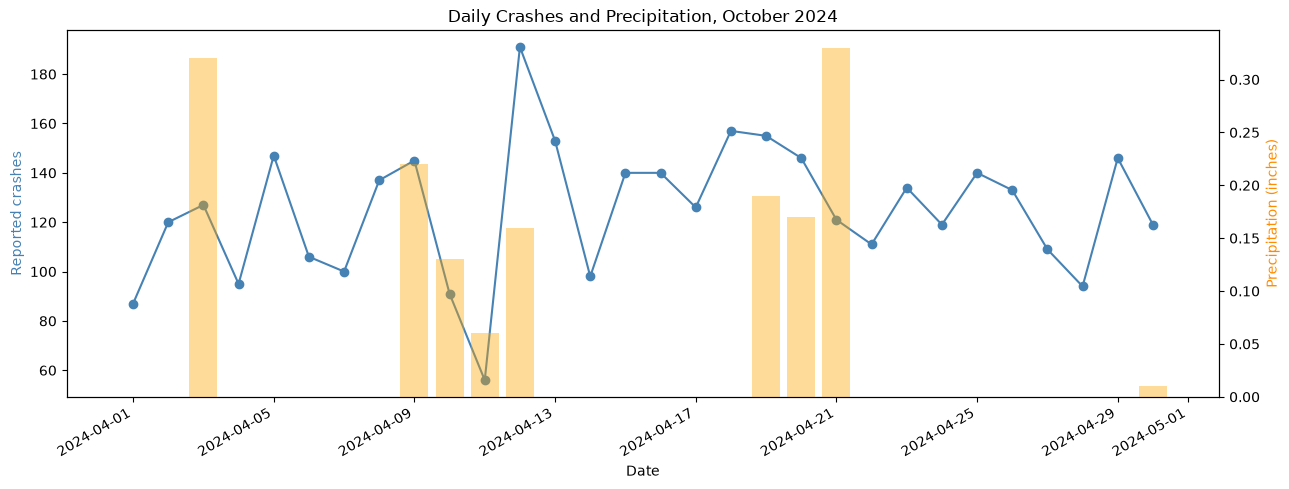

In [21]:
daily_view = daily_comparison.loc[
    daily_comparison["DATE"].dt.to_period("M") == "2024-04",
    ["DATE", "PRCP", "TMAX", "TMIN", "crash_count"]
].copy()

daily_view["day_of_week"] = daily_view["DATE"].dt.day_name()

display(daily_view[
    ["DATE", "day_of_week", "PRCP", "TMAX", "TMIN", "crash_count"]
])

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(
    daily_view["DATE"], daily_view["crash_count"],
    color="steelblue", marker="o", label="Crashes"
)
ax1.set_ylabel("Reported crashes", color="steelblue")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.bar(
    daily_view["DATE"], daily_view["PRCP"],
    color="orange", alpha=0.4, label="Precipitation"
)
ax2.set_ylabel("Precipitation (inches)", color="darkorange")

plt.title("Daily Crashes and Precipitation, October 2024")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

,day_type,rain_level,days,avg_crashes
0,Weekday,Dry,1243,114.3
1,Weekday,Light,194,107.0
2,Weekday,Moderate,230,117.6
3,Weekday,Heavy,160,125.8
4,Weekend,Dry,486,89.0
5,Weekend,Light,88,85.9
6,Weekend,Moderate,90,97.5
7,Weekend,Heavy,66,97.8


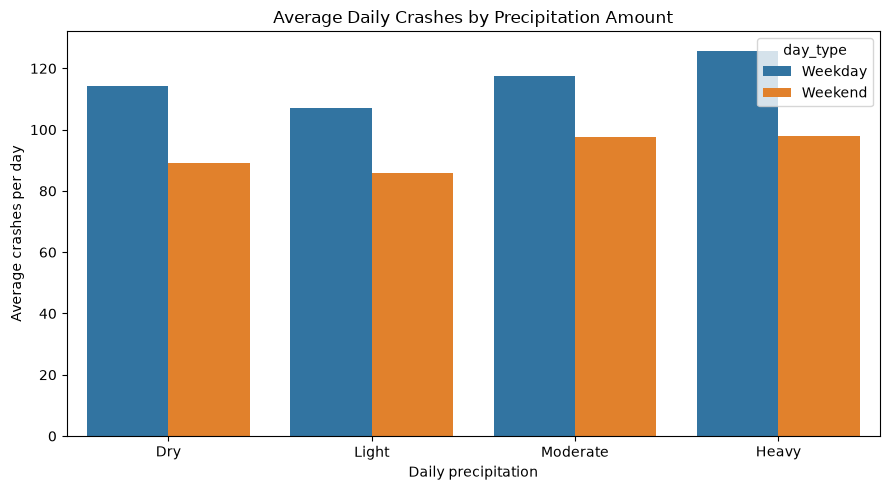

In [22]:
daily_comparison["day_type"] = np.where(
    daily_comparison["DATE"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

daily_comparison["rain_level"] = pd.cut(
    daily_comparison["PRCP"],
    bins=[-0.001, 0, 0.10, 0.50, np.inf],
    labels=["Dry", "Light", "Moderate", "Heavy"]
)

rain_summary = (
    daily_comparison
    .groupby(["day_type", "rain_level"], observed=True)["crash_count"]
    .agg(days="size", avg_crashes="mean")
    .reset_index()
)

rain_summary["avg_crashes"] = rain_summary["avg_crashes"].round(1)
display(rain_summary)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=rain_summary,
    x="rain_level",
    y="avg_crashes",
    hue="day_type"
)
plt.title("Average Daily Crashes by Precipitation Amount")
plt.xlabel("Daily precipitation")
plt.ylabel("Average crashes per day")
plt.tight_layout()
plt.show()

## From crash points to monthly prediction rows

I use the dataset's projected X and Y coordinates to place each crash in a square cell about 500 meters wide. The target is the number of distinct crash IDs in each cell and month. Of the 276,118 crashes retained for exploration, the positive cell-month table includes 4,314 observed cells across 2018–2024.

In [23]:
cell_size_ft = 500 * (3937 / 1200)  # 500 meters in US survey feet

crashes["cell_x"] = np.floor(crashes["X"] / cell_size_ft).astype(int)
crashes["cell_y"] = np.floor(crashes["Y"] / cell_size_ft).astype(int)
crashes["month"] = crashes["local_date"].dt.to_period("M").dt.to_timestamp()

cell_month_counts = (
    crashes.groupby(["cell_x", "cell_y", "month"])["CRSH_ID"]
    .nunique()
    .reset_index(name="crash_count")
)

print("Map cells:", cell_month_counts[["cell_x", "cell_y"]].drop_duplicates().shape[0])
print("Area-months with crashes:", len(cell_month_counts))
print("Crashes counted:", cell_month_counts["crash_count"].sum())
display(cell_month_counts.head())

Map cells: 4314
Area-months with crashes: 107630
Crashes counted: 276118


,cell_x,cell_y,month,crash_count
0,835,338,2022-06-01,1
1,844,296,2020-03-01,1
2,844,298,2022-08-01,1
3,845,294,2020-06-01,1
4,845,296,2019-12-01,1


I define the study area using the 4,146 cells observed **before 2023**. Each of those cells gets a row for every month from January 2018 to December 2024, even if its count is zero. This avoids using future observations to choose the cells being evaluated. It creates 348,264 cell-month rows, including 240,867 zero-crash rows. A few crashes in cells first observed after 2022 fall outside this fixed study area.

In [24]:
training_cells = (
    crashes.loc[crashes["month"] < "2023-01-01", ["cell_x", "cell_y"]]
    .drop_duplicates()
)

all_months = pd.DataFrame({
    "month": pd.date_range("2018-01-01", "2024-12-01", freq="MS")
})

all_cell_months = training_cells.merge(all_months, how="cross")

model_data = all_cell_months.merge(
    cell_month_counts,
    on=["cell_x", "cell_y", "month"],
    how="left",
    validate="one_to_one"
)

model_data["crash_count"] = (
    model_data["crash_count"].fillna(0).astype(int)
)

print("Training-period cells:", len(training_cells))
print("Total area-month rows:", len(model_data))
print("Zero-crash rows:", (model_data["crash_count"] == 0).sum())
display(model_data.head())

Training-period cells: 4146
Total area-month rows: 348264
Zero-crash rows: 240867


,cell_x,cell_y,month,crash_count
0,884,327,2018-01-01,4
1,884,327,2018-02-01,5
2,884,327,2018-03-01,8
3,884,327,2018-04-01,7
4,884,327,2018-05-01,8


### Features available before the forecast month

For each cell, the features record its grid position, calendar month, crash count last month, and average count over the prior three months. The later 12-month average gives a steadier measure of the cell's history. Each history calculation shifts the counts back one month, so the model never receives the month it is trying to predict. The first three months lack enough history and are left out of model training.

In [25]:
model_data = model_data.sort_values(
    ["cell_x", "cell_y", "month"]
).reset_index(drop=True)

by_cell = model_data.groupby(["cell_x", "cell_y"])["crash_count"]

model_data["last_month_crashes"] = by_cell.shift(1)

model_data["avg_last_3_months"] = by_cell.transform(
    lambda counts: counts.shift(1).rolling(3).mean()
)

model_data["month_number"] = model_data["month"].dt.month

display(
    model_data.loc[
        (model_data["cell_x"] == 884) &
        (model_data["cell_y"] == 327)
    ].head(6)
)

,cell_x,cell_y,month,crash_count,last_month_crashes,avg_last_3_months,month_number
168000,884,327,2018-01-01,4,NaN,NaN,1
168001,884,327,2018-02-01,5,4.0,NaN,2
168002,884,327,2018-03-01,8,5.0,NaN,3
168003,884,327,2018-04-01,7,8.0,5.666667,4
168004,884,327,2018-05-01,8,7.0,6.666667,5
168005,884,327,2018-06-01,4,8.0,7.666667,6


## Models and evaluation plan

I train on April 2018 through December 2022 and use 2023 to compare model settings. The 2024 rows are used for the final evaluation. This is a rolling one-month-ahead setup: when predicting a later month in 2024, the model may use **actual counts from earlier 2024 months**, as it would in a monthly update.

The simple baseline predicts the average of the previous three months in the same cell. I compare it with a decision tree and linear regression. **Mean absolute error (MAE)** is the average size of a prediction error in crashes per cell-month; lower is better. For the hotspot goal, I also rank the highest-predicted 5% of cells each month and report what share of actual crashes occurred in those cells; higher is better.

In [26]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

features = [
    "cell_x", "cell_y", "month_number",
    "last_month_crashes", "avg_last_3_months"
]

model_ready = model_data.dropna(subset=features).copy()

train = model_ready[model_ready["month"] < "2023-01-01"]
validation = model_ready[
    (model_ready["month"] >= "2023-01-01") &
    (model_ready["month"] < "2024-01-01")
]
test = model_ready[model_ready["month"] >= "2024-01-01"]

tree = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=50,
    random_state=42
)

tree.fit(train[features], train["crash_count"])

tree_predictions = tree.predict(validation[features])
baseline_predictions = validation["avg_last_3_months"]

print("Training rows:", len(train))
print("Validation rows:", len(validation))
print("Test rows held aside:", len(test))
print(
    "3-month average MAE:",
    round(mean_absolute_error(validation["crash_count"], baseline_predictions), 3)
)
print(
    "Decision tree MAE:",
    round(mean_absolute_error(validation["crash_count"], tree_predictions), 3)
)

Training rows: 236322
Validation rows: 49752
Test rows held aside: 49752
3-month average MAE: 0.585
Decision tree MAE: 0.618


### Improving the tree

The first decision tree did worse than the three-month baseline on 2023. I tried several limits on tree depth and minimum leaf size using only the 2023 validation results. Changing these settings alone did not beat the baseline, so the next experiment adds a longer view of crash history.

In [27]:
results = []

for depth in [6, 10, 14]:
    for leaf_size in [20, 100, 300]:
        candidate = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=leaf_size,
            random_state=42
        )

        candidate.fit(train[features], train["crash_count"])
        predictions = candidate.predict(validation[features])

        results.append({
            "max_depth": depth,
            "min_samples_leaf": leaf_size,
            "validation_MAE": mean_absolute_error(
                validation["crash_count"], predictions
            )
        })

tree_results = (
    pd.DataFrame(results)
    .sort_values("validation_MAE")
    .reset_index(drop=True)
)

display(tree_results.round(3))

,max_depth,min_samples_leaf,validation_MAE
0,14,300,0.615
1,14,100,0.616
2,10,300,0.617
3,10,100,0.618
4,6,300,0.619
5,6,100,0.620
6,10,20,0.620
7,6,20,0.621
8,14,20,0.621


In [28]:
best_tree = DecisionTreeRegressor(
    max_depth=14,
    min_samples_leaf=300,
    random_state=42
)
best_tree.fit(train[features], train["crash_count"])

ranking = validation[
    ["month", "cell_x", "cell_y", "crash_count"]
].copy()

ranking["tree_pred"] = best_tree.predict(validation[features])
ranking["baseline_pred"] = validation["avg_last_3_months"].to_numpy()

top_n = round(len(training_cells) * 0.05)
ranking_results = []

for month, month_data in ranking.groupby("month"):
    total_crashes = month_data["crash_count"].sum()

    for method in ["baseline_pred", "tree_pred"]:
        top_cells = month_data.nlargest(top_n, method)
        ranking_results.append({
            "month": month,
            "method": method,
            "crashes_in_top_cells": top_cells["crash_count"].sum(),
            "share_of_monthly_crashes":
                top_cells["crash_count"].sum() / total_crashes
        })

ranking_results = pd.DataFrame(ranking_results)

display(
    ranking_results
    .groupby("method")["share_of_monthly_crashes"]
    .mean()
    .mul(100)
    .round(1)
    .rename("Average percent of crashes in top 5% of cells")
)

method
baseline_pred    40.7
tree_pred        40.7
Name: Average percent of crashes in top 5% of cells, dtype: float64

The prior 12-month average improved the tree's 2023 MAE to **0.571**, compared with **0.585** for the baseline. It also lifted the share of crashes in the predicted top 5% of cells from **40.7% to 41.5%**. A longer history helped more than tree tuning alone.

In [29]:
by_cell = model_data.groupby(["cell_x", "cell_y"])["crash_count"]

model_data["avg_last_12_months"] = by_cell.transform(
    lambda counts: counts.shift(1).rolling(12, min_periods=3).mean()
)

features_plus = features + ["avg_last_12_months"]

train_plus = model_data[
    (model_data["month"] < "2023-01-01") &
    model_data["avg_last_12_months"].notna()
]

validation_plus = model_data[
    (model_data["month"] >= "2023-01-01") &
    (model_data["month"] < "2024-01-01")
]

tree_plus = DecisionTreeRegressor(
    max_depth=14,
    min_samples_leaf=300,
    random_state=42
)

tree_plus.fit(train_plus[features_plus], train_plus["crash_count"])
plus_predictions = tree_plus.predict(validation_plus[features_plus])

print(
    "Tree with longer history MAE:",
    round(mean_absolute_error(
        validation_plus["crash_count"], plus_predictions
    ), 3)
)

Tree with longer history MAE: 0.571


In [35]:
ranking_plus = validation_plus[
    ["month", "cell_x", "cell_y", "crash_count"]
].copy()

ranking_plus["tree_pred"] = plus_predictions
ranking_plus["baseline_pred"] = validation_plus[
    "avg_last_3_months"
].to_numpy()

top_n = round(len(training_cells) * 0.05)
results_plus = []

for month, month_data in ranking_plus.groupby("month"):
    total_crashes = month_data["crash_count"].sum()

    for method in ["baseline_pred", "tree_pred"]:
        top_cells = month_data.nlargest(top_n, method)

        results_plus.append({
            "month": month,
            "method": method,
            "share": top_cells["crash_count"].sum() / total_crashes
        })

display(
    pd.DataFrame(results_plus)
    .groupby("method")["share"]
    .mean()
    .mul(100)
    .round(1)
    .rename("Percent of crashes in predicted top 5% of cells")
)

method
baseline_pred    40.7
tree_pred        41.5
Name: Percent of crashes in predicted top 5% of cells, dtype: float64

In [36]:
final_train = model_data[
    (model_data["month"] < "2024-01-01") &
    model_data["avg_last_12_months"].notna()
]

final_test = model_data[
    model_data["month"] >= "2024-01-01"
].copy()

final_tree = DecisionTreeRegressor(
    max_depth=14,
    min_samples_leaf=300,
    random_state=42
)
final_tree.fit(final_train[features_plus], final_train["crash_count"])

final_test["tree_pred"] = final_tree.predict(final_test[features_plus])
final_test["baseline_pred"] = final_test["avg_last_3_months"]

print("2024 rows:", len(final_test))
print(
    "Baseline MAE:",
    round(mean_absolute_error(
        final_test["crash_count"], final_test["baseline_pred"]
    ), 3)
)
print(
    "Decision tree MAE:",
    round(mean_absolute_error(
        final_test["crash_count"], final_test["tree_pred"]
    ), 3)
)

top_n = round(len(training_cells) * 0.05)

for method in ["baseline_pred", "tree_pred"]:
    monthly_shares = []

    for _, month_data in final_test.groupby("month"):
        top_cells = month_data.nlargest(top_n, method)
        monthly_shares.append(
            top_cells["crash_count"].sum() /
            month_data["crash_count"].sum()
        )

    print(
        method, "top 5% crash share:",
        round(100 * np.mean(monthly_shares), 1), "%"
    )

2024 rows: 49752
Baseline MAE: 0.588
Decision tree MAE: 0.568
baseline_pred top 5% crash share: 40.0 %
tree_pred top 5% crash share: 41.0 %


### Comparing the second machine learning model

I then fit linear regression using the same features and validation period. Predictions below zero are clipped to zero because a crash count cannot be negative. On 2023, linear regression had the lowest MAE: **0.565**, compared with **0.571** for the tree and **0.585** for the baseline. The notebook had already displayed a 2024 tree result before the linear model was added, so the 2024 comparison should be described as a held-out-year assessment with that model-development history made clear, rather than as a completely untouched blind test for every decision.

In [37]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(train_plus[features_plus], train_plus["crash_count"])

linear_predictions = np.clip(
    linear_model.predict(validation_plus[features_plus]),
    0, None
)

print("2023 baseline MAE:", round(
    mean_absolute_error(
        validation_plus["crash_count"],
        validation_plus["avg_last_3_months"]
    ), 3
))
print("2023 linear regression MAE:", round(
    mean_absolute_error(
        validation_plus["crash_count"],
        linear_predictions
    ), 3
))
print("2023 decision tree MAE:", round(
    mean_absolute_error(
        validation_plus["crash_count"],
        plus_predictions
    ), 3
))

2023 baseline MAE: 0.585
2023 linear regression MAE: 0.565
2023 decision tree MAE: 0.571


In [38]:
final_linear = LinearRegression()
final_linear.fit(final_train[features_plus], final_train["crash_count"])

final_test["linear_pred"] = np.clip(
    final_linear.predict(final_test[features_plus]),
    0, None
)

print("2024 baseline MAE:", round(
    mean_absolute_error(
        final_test["crash_count"], final_test["baseline_pred"]
    ), 3
))
print("2024 linear regression MAE:", round(
    mean_absolute_error(
        final_test["crash_count"], final_test["linear_pred"]
    ), 3
))
print("2024 decision tree MAE:", round(
    mean_absolute_error(
        final_test["crash_count"], final_test["tree_pred"]
    ), 3
))

top_n = round(len(training_cells) * 0.05)

for method in ["baseline_pred", "linear_pred", "tree_pred"]:
    shares = []

    for _, month_data in final_test.groupby("month"):
        top_cells = month_data.nlargest(top_n, method)
        shares.append(
            top_cells["crash_count"].sum() /
            month_data["crash_count"].sum()
        )

    print(method, "top 5% crash share:", round(np.mean(shares) * 100, 1), "%")
    

2024 baseline MAE: 0.588
2024 linear regression MAE: 0.564
2024 decision tree MAE: 0.568
baseline_pred top 5% crash share: 40.0 %
linear_pred top 5% crash share: 41.1 %
tree_pred top 5% crash share: 41.0 %


## What the 2024 results mean

On the 2024 rows, the baseline MAE is **0.588**, the tree MAE is **0.568**, and linear regression is best at **0.564**. The predicted top 5% of cells contain **40.0%**, **41.0%**, and **41.1%** of actual crashes, respectively. The improvement over the baseline is real in this test but modest. The error table below checks whether performance changes between quiet and busy cells.

In [40]:
final_test["count_group"] = pd.cut(
    final_test["crash_count"],
    bins=[-1, 0, 1, 4, np.inf],
    labels=["0 crashes", "1 crash", "2–4 crashes", "5+ crashes"]
)

final_test["linear_abs_error"] = (
    final_test["crash_count"] - final_test["linear_pred"]
).abs()

error_review = (
    final_test.groupby("count_group", observed=True)
    .agg(
        area_months=("crash_count", "size"),
        avg_actual=("crash_count", "mean"),
        avg_predicted=("linear_pred", "mean"),
        MAE=("linear_abs_error", "mean")
    )
    .round(2)
)

display(error_review)

,area_months,avg_actual,avg_predicted,MAE
count_group,,,,
0 crashes,33628,0.00,0.27,0.27
1 crash,7802,1.00,0.81,0.69
2–4 crashes,5727,2.64,2.16,1.29
5+ crashes,2595,7.84,6.38,2.45


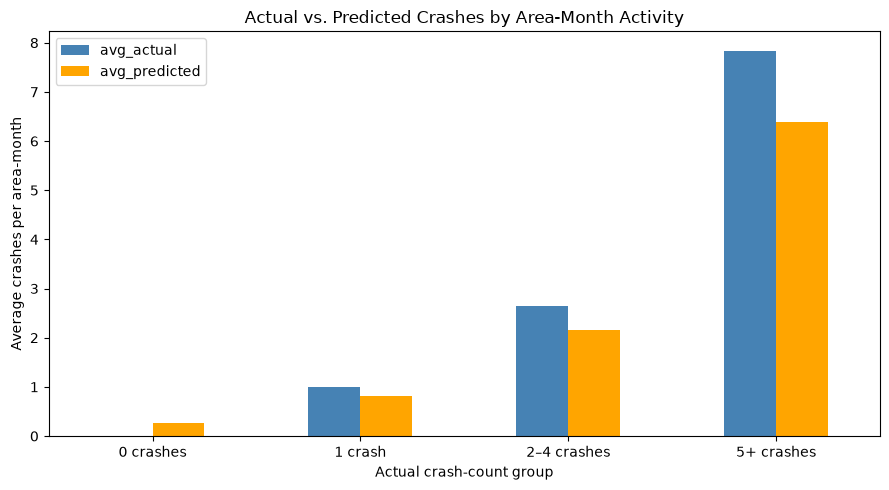

In [41]:
error_review[["avg_actual", "avg_predicted"]].plot.bar(
    figsize=(9, 5),
    color=["steelblue", "orange"]
)
plt.title("Actual vs. Predicted Crashes by Area-Month Activity")
plt.xlabel("Actual crash-count group")
plt.ylabel("Average crashes per area-month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The linear model tends to predict too few crashes in the busiest cell-months: those with five or more crashes averaged **7.84 actual** versus **6.38 predicted**. The permutation check below tests how much the MAE increases when each feature is shuffled. The prior 12-month average is the strongest feature by far. Recent counts add less, and location and calendar month add little once past counts are included. Because these history features overlap, their importance values should not be read as independent causal effects.

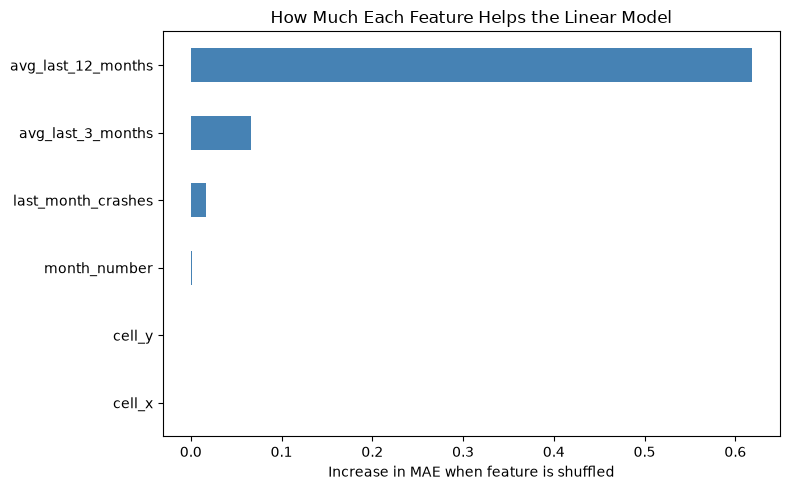

avg_last_12_months    0.618
avg_last_3_months     0.066
last_month_crashes    0.017
month_number          0.001
cell_y                0.000
cell_x               -0.000
dtype: float64

In [42]:
from sklearn.inspection import permutation_importance

def negative_clipped_mae(model, X, y):
    predictions = np.clip(model.predict(X), 0, None)
    return -mean_absolute_error(y, predictions)

importance = permutation_importance(
    final_linear,
    final_test[features_plus],
    final_test["crash_count"],
    scoring=negative_clipped_mae,
    n_repeats=3,
    random_state=42
)

feature_importance = (
    pd.Series(importance.importances_mean, index=features_plus)
    .sort_values()
)

feature_importance.plot.barh(figsize=(8, 5), color="steelblue")
plt.title("How Much Each Feature Helps the Linear Model")
plt.xlabel("Increase in MAE when feature is shuffled")
plt.tight_layout()
plt.show()

display(feature_importance.sort_values(ascending=False).round(3))

## Morning and afternoon extension

The main forecast counts all crashes in a month. I also test whether it helps to forecast **morning (6–11 a.m.)** and **afternoon (noon–6 p.m.)** crashes separately. The remaining hours stay in an `other` group for accounting but are not a separate prediction target here. This extension uses the same study cells, split years, and previous-month-only approach.

In [43]:
crash_time = pd.to_numeric(crashes["MILT_TIME"], errors="coerce")
hour = crash_time // 100
minute = crash_time % 100

valid_time = hour.between(0, 23) & minute.between(0, 59)

print("Crashes with a valid time:", valid_time.sum())
print("Crashes with a missing or invalid time:", (~valid_time).sum())
print("\nCrashes by hour:")
display(hour[valid_time].astype(int).value_counts().sort_index())

Crashes with a valid time: 276118
Crashes with a missing or invalid time: 0

Crashes by hour:


MILT_TIME
0      4360
1      3503
2      4166
3      2513
4      1924
5      2506
6      6793
7     12614
8     13601
9     11936
10    12076
11    14405
12    17281
13    17748
14    19065
15    21038
16    21647
17    22852
18    18873
19    13334
20    10727
21     9317
22     7808
23     6031
Name: count, dtype: int64

In [44]:
crashes["time_period"] = np.select(
    [
        hour.between(6, 11),
        hour.between(12, 18)
    ],
    ["morning", "afternoon"],
    default="other"
)

crashes.loc[~valid_time, "time_period"] = "invalid"

print(crashes["time_period"].value_counts())

time_period
afternoon    138504
morning       71425
other         66189
Name: count, dtype: int64


In [45]:
periods = ["morning", "afternoon"]

period_counts = (
    crashes[crashes["time_period"].isin(periods)]
    .groupby(["cell_x", "cell_y", "DATE_VAL_YEAR",
              "DATE_VAL_MONTH", "time_period"])["CRSH_ID"]
    .nunique()
    .reset_index(name="crash_count")
)

period_counts["month"] = pd.to_datetime(
    dict(
        year=period_counts["DATE_VAL_YEAR"],
        month=period_counts["DATE_VAL_MONTH"],
        day=1
    )
)

cell_months = model_data[["cell_x", "cell_y", "month"]].drop_duplicates()

period_data = pd.concat(
    [cell_months.assign(time_period=period) for period in periods],
    ignore_index=True
)

period_data = period_data.merge(
    period_counts[["cell_x", "cell_y", "month",
                   "time_period", "crash_count"]],
    on=["cell_x", "cell_y", "month", "time_period"],
    how="left"
)

period_data["crash_count"] = (
    period_data["crash_count"].fillna(0).astype(int)
)

print("Rows:", len(period_data))
print("Crashes counted by period:")
print(period_data.groupby("time_period")["crash_count"].sum())
display(period_data.head())

Rows: 696528
Crashes counted by period:
time_period
afternoon    138394
morning       71352
Name: crash_count, dtype: int64


,cell_x,cell_y,month,time_period,crash_count
0,835,338,2018-01-01,morning,0
1,835,338,2018-02-01,morning,0
2,835,338,2018-03-01,morning,0
3,835,338,2018-04-01,morning,0
4,835,338,2018-05-01,morning,0


In [46]:
period_data = period_data.sort_values(
    ["cell_x", "cell_y", "time_period", "month"]
).reset_index(drop=True)

by_cell_period = period_data.groupby(
    ["cell_x", "cell_y", "time_period"]
)["crash_count"]

period_data["last_period_month"] = by_cell_period.shift(1)

period_data["avg_last_3_period_months"] = by_cell_period.transform(
    lambda counts: counts.shift(1).rolling(3).mean()
)

period_data["avg_last_12_period_months"] = by_cell_period.transform(
    lambda counts: counts.shift(1).rolling(12, min_periods=3).mean()
)

period_data["month_number"] = period_data["month"].dt.month
period_data["is_afternoon"] = (
    period_data["time_period"] == "afternoon"
).astype(int)

display(period_data[
    ["cell_x", "cell_y", "month", "time_period", "crash_count",
     "last_period_month", "avg_last_3_period_months",
     "avg_last_12_period_months"]
].head(16))

,cell_x,cell_y,month,time_period,crash_count,last_period_month,avg_last_3_period_months,avg_last_12_period_months
0,835,338,2018-01-01,afternoon,0,NaN,NaN,NaN
1,835,338,2018-02-01,afternoon,0,0.0,NaN,NaN
2,835,338,2018-03-01,afternoon,0,0.0,NaN,NaN
3,835,338,2018-04-01,afternoon,0,0.0,0.0,0.0
4,835,338,2018-05-01,afternoon,0,0.0,0.0,0.0
5,835,338,2018-06-01,afternoon,0,0.0,0.0,0.0
6,835,338,2018-07-01,afternoon,0,0.0,0.0,0.0
7,835,338,2018-08-01,afternoon,0,0.0,0.0,0.0
8,835,338,2018-09-01,afternoon,0,0.0,0.0,0.0
9,835,338,2018-10-01,afternoon,0,0.0,0.0,0.0


For each cell and time period, I calculate its own last-month, prior-three-month, and prior-12-month crash history. A linear model also receives an indicator for afternoon. Comparing errors **within each period** matters because afternoon has more crashes than morning, and an overall error could hide weak morning performance.

In [47]:
period_features = [
    "cell_x", "cell_y", "month_number", "is_afternoon",
    "last_period_month",
    "avg_last_3_period_months",
    "avg_last_12_period_months"
]

train_period = period_data[
    (period_data["month"] < "2023-01-01") &
    period_data["avg_last_12_period_months"].notna()
]

validation_period = period_data[
    (period_data["month"] >= "2023-01-01") &
    (period_data["month"] < "2024-01-01")
].copy()

period_linear = LinearRegression()
period_linear.fit(
    train_period[period_features],
    train_period["crash_count"]
)

validation_period["baseline_pred"] = (
    validation_period["avg_last_3_period_months"]
)
validation_period["linear_pred"] = np.clip(
    period_linear.predict(validation_period[period_features]),
    0, None
)

for period, rows in validation_period.groupby("time_period"):
    print(f"\n{period.title()} 2023:")
    for method in ["baseline_pred", "linear_pred"]:
        mae = mean_absolute_error(
            rows["crash_count"], rows[method]
        )
        print(f"  {method}: {mae:.3f} MAE")


Afternoon 2023:
  baseline_pred: 0.376 MAE
  linear_pred: 0.371 MAE

Morning 2023:
  baseline_pred: 0.254 MAE
  linear_pred: 0.250 MAE


In [48]:
top_n = round(
    validation_period[["cell_x", "cell_y"]].drop_duplicates().shape[0] * 0.05
)

for period, period_rows in validation_period.groupby("time_period"):
    print(f"\n{period.title()} top 5% of cells:")

    for method in ["baseline_pred", "linear_pred"]:
        shares = []

        for _, month_rows in period_rows.groupby("month"):
            top_cells = month_rows.nlargest(top_n, method)
            share = (
                top_cells["crash_count"].sum()
                / month_rows["crash_count"].sum()
            )
            shares.append(share)

        print(f"  {method}: {np.mean(shares) * 100:.1f}% of crashes")


Afternoon top 5% of cells:
  baseline_pred: 40.3% of crashes
  linear_pred: 41.8% of crashes

Morning top 5% of cells:
  baseline_pred: 35.6% of crashes
  linear_pred: 38.7% of crashes


In [49]:
final_period_train = period_data[
    (period_data["month"] < "2024-01-01") &
    period_data["avg_last_12_period_months"].notna()
]

final_period_test = period_data[
    period_data["month"] >= "2024-01-01"
].copy()

final_period_linear = LinearRegression()
final_period_linear.fit(
    final_period_train[period_features],
    final_period_train["crash_count"]
)

final_period_test["baseline_pred"] = (
    final_period_test["avg_last_3_period_months"]
)
final_period_test["linear_pred"] = np.clip(
    final_period_linear.predict(final_period_test[period_features]),
    0, None
)

for period, rows in final_period_test.groupby("time_period"):
    print(f"\n{period.title()} 2024:")

    for method in ["baseline_pred", "linear_pred"]:
        mae = mean_absolute_error(rows["crash_count"], rows[method])

        shares = []
        for _, month_rows in rows.groupby("month"):
            top_cells = month_rows.nlargest(top_n, method)
            shares.append(
                top_cells["crash_count"].sum()
                / month_rows["crash_count"].sum()
            )

        print(
            f"  {method}: MAE {mae:.3f}, "
            f"top 5% captured {np.mean(shares) * 100:.1f}%"
        )


Afternoon 2024:
  baseline_pred: MAE 0.374, top 5% captured 40.0%
  linear_pred: MAE 0.368, top 5% captured 42.0%

Morning 2024:
  baseline_pred: MAE 0.256, top 5% captured 34.5%
  linear_pred: MAE 0.253, top 5% captured 38.3%


In [51]:
comparison = final_period_test.merge(
    final_test[["cell_x", "cell_y", "month", "linear_pred"]]
    .rename(columns={"linear_pred": "monthly_model_pred"}),
    on=["cell_x", "cell_y", "month"],
    how="left",
    validate="many_to_one"
)

for period, rows in comparison.groupby("time_period"):
    print(f"\n{period.title()} crashes in top 5% of cells:")

    for prediction in ["monthly_model_pred", "linear_pred"]:
        shares = []

        for _, month_rows in rows.groupby("month"):
            top_cells = month_rows.nlargest(top_n, prediction)
            shares.append(
                top_cells["crash_count"].sum()
                / month_rows["crash_count"].sum()
            )

        print(f"  {prediction}: {np.mean(shares) * 100:.1f}%")


Afternoon crashes in top 5% of cells:
  monthly_model_pred: 41.9%
  linear_pred: 42.0%

Morning crashes in top 5% of cells:
  monthly_model_pred: 38.5%
  linear_pred: 38.3%


### Comparing the hotspot maps

Across 2024, the separate model's predicted top 5% of cells contained **42.0% of afternoon** and **38.3% of morning** crashes. The original all-day model's ranking contained **41.9% of afternoon** and **38.5% of morning** crashes. The separate forecasts therefore add little to the hotspot ranking.

The maps below show **December 2024 test predictions** and the cells with the most reported crashes that month. The axes are grid columns and rows, rather than street names. These retrospective predictions use earlier crash counts, including November 2024, but do not use December's crash counts as input.

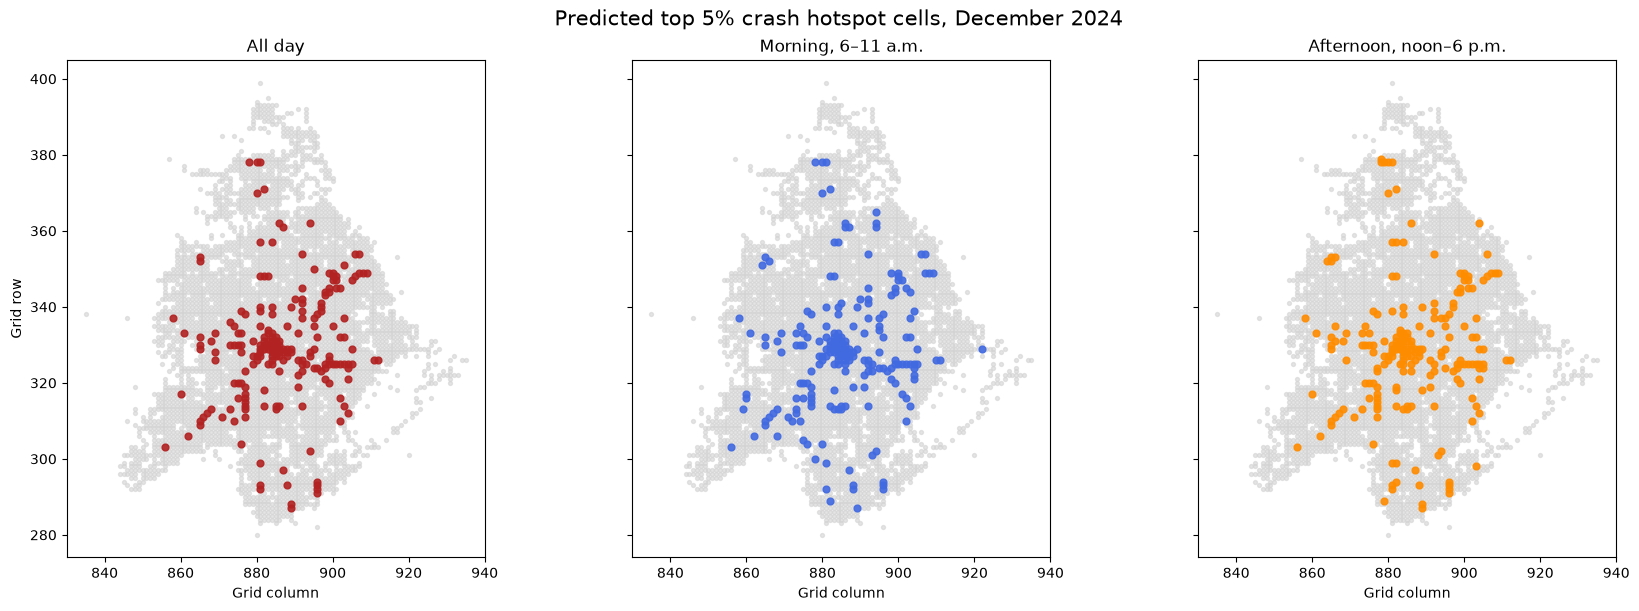

In [ ]:
month_to_plot = pd.Timestamp("2024-12-01")

monthly_rows = final_test[
    final_test["month"] == month_to_plot
]

morning_rows = final_period_test[
    (final_period_test["month"] == month_to_plot) &
    (final_period_test["time_period"] == "morning")
]

afternoon_rows = final_period_test[
    (final_period_test["month"] == month_to_plot) &
    (final_period_test["time_period"] == "afternoon")
]

maps = [
    ("All day", monthly_rows, "firebrick"),
    ("Morning, 6–11 a.m.", morning_rows, "royalblue"),
    ("Afternoon, noon–6 p.m.", afternoon_rows, "darkorange")
]

fig, axes = plt.subplots(
    1, 3, figsize=(17, 6),
    sharex=True, sharey=True,
    constrained_layout=True
)

for ax, (title, rows, color) in zip(axes, maps):
    top_cells = rows.nlargest(top_n, "linear_pred")

    ax.scatter(
        rows["cell_x"], rows["cell_y"],
        s=8, color="lightgray", alpha=0.6
    )
    ax.scatter(
        top_cells["cell_x"], top_cells["cell_y"],
        s=24, color=color, alpha=0.9
    )

    ax.set_title(title)
    ax.set_xlabel("Grid column")
    ax.set_aspect("equal")

axes[0].set_ylabel("Grid row")
fig.suptitle(
    "Predicted top 5% crash hotspot cells, December 2024 - predicted by linear regression model",
    fontsize=15
)
plt.show()

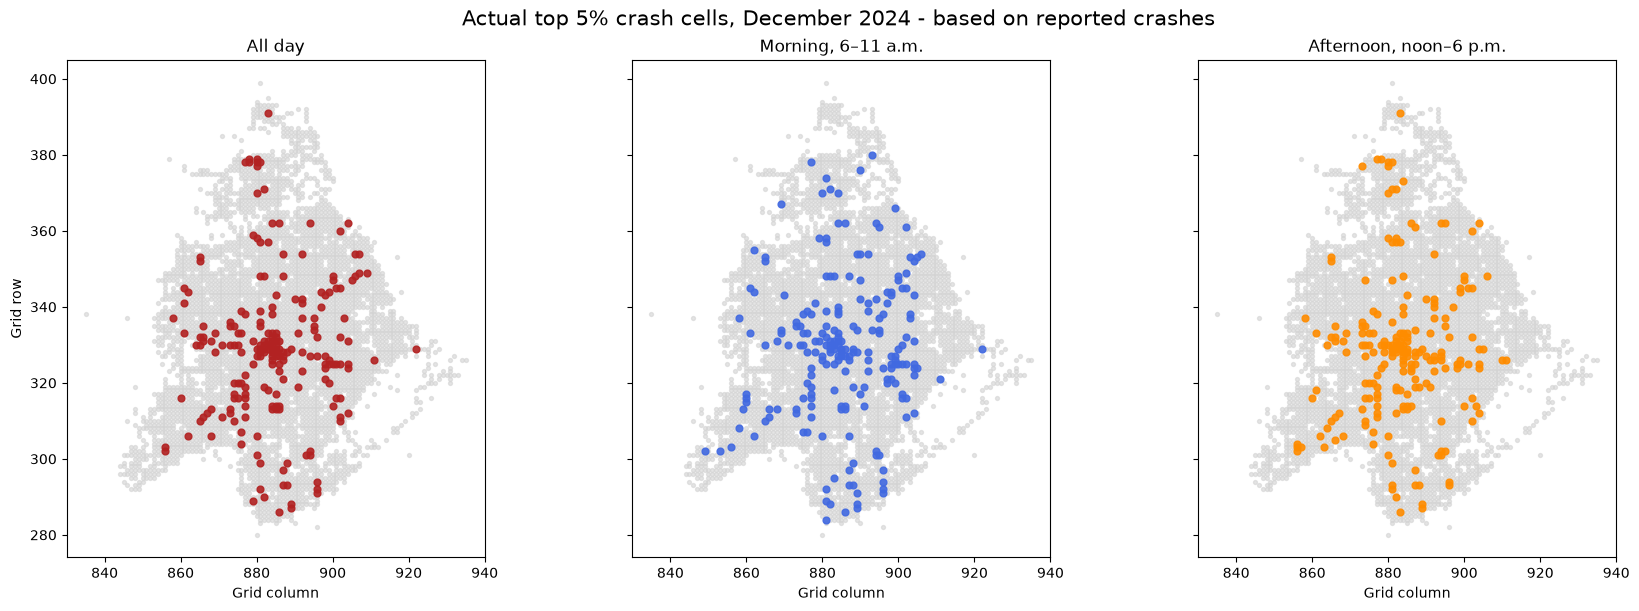

In [55]:
maps_actual = [
    ("All day", monthly_rows, "firebrick"),
    ("Morning, 6–11 a.m.", morning_rows, "royalblue"),
    ("Afternoon, noon–6 p.m.", afternoon_rows, "darkorange")
]

fig, axes = plt.subplots(
    1, 3, figsize=(17, 6),
    sharex=True, sharey=True,
    constrained_layout=True
)

for ax, (title, rows, color) in zip(axes, maps_actual):
    actual_top = rows.nlargest(top_n, "crash_count")

    ax.scatter(
        rows["cell_x"], rows["cell_y"],
        s=8, color="lightgray", alpha=0.6
    )
    ax.scatter(
        actual_top["cell_x"], actual_top["cell_y"],
        s=24, color=color, alpha=0.9
    )

    ax.set_title(title)
    ax.set_xlabel("Grid column")
    ax.set_aspect("equal")

axes[0].set_ylabel("Grid row")
fig.suptitle(
    "Actual top 5% crash cells, December 2024 - based on reported crashes",
    fontsize=15
)
plt.show()

In [56]:
for name, rows in [
    ("All day", monthly_rows),
    ("Morning", morning_rows),
    ("Afternoon", afternoon_rows)
]:
    predicted_top = rows.nlargest(top_n, "linear_pred")
    captured = predicted_top["crash_count"].sum()
    total = rows["crash_count"].sum()

    print(
        f"{name}: {captured} of {total} December crashes "
        f"({captured / total:.1%}) occurred in predicted top 5% of cells"
    )

All day: 1604 of 3864 December crashes (41.5%) occurred in predicted top 5% of cells
Morning: 406 of 1058 December crashes (38.4%) occurred in predicted top 5% of cells
Afternoon: 855 of 2009 December crashes (42.6%) occurred in predicted top 5% of cells


## Answer, limitations, and next steps

Past crash patterns gave a useful, though imperfect, picture of where Charlotte's reported crashes would be concentrated the next month. In December 2024, the predicted top 5% of cells contained **1,604 of 3,864 crashes (41.5%)**. The predicted morning cells contained **406 of 1,058 (38.4%)**, and the predicted afternoon cells contained **855 of 2,009 (42.6%)**. Many crashes still occurred outside the selected cells. The main monthly linear model is the clearest result; separate time-of-day forecasts did not materially improve the ranking.

This model estimates **reported crash counts**, not the probability that an individual driver will crash. It does not adjust for traffic volume, miles traveled, road design, construction, or changes in reporting. The fixed study cells omit areas first recorded after 2022, and the many zero-count rows make it easier to achieve a low overall MAE while missing some busy cells. The airport weather comparison cannot establish that rain caused a change in crashes. Forecast errors could direct attention away from a cell that later has many crashes, so these rankings should support investigation rather than be treated as a safety decision by themselves. A future project could add road and traffic exposure data and evaluate performance on later years.

### Sources (APA style)

- Charlotte Department of Transportation. (n.d.). *Crashes* [Data set]. City of Charlotte ArcGIS REST Services. https://gis.charlottenc.gov/arcgis/rest/services/CDOT/TCLS_Crashes/MapServer/0
- Federal Highway Administration. (n.d.-a). *Rain & flooding*. U.S. Department of Transportation. https://ops.fhwa.dot.gov/weather/weather_events/rain_flooding.htm
- Federal Highway Administration. (n.d.-b). *Screening your network to improve roadway safety performance: Getting started*. U.S. Department of Transportation. https://highways.dot.gov/safety/data-analysis-tools/systemic/screening-your-network-improve-roadway-safety-performance
- National Centers for Environmental Information. (n.d.). *Charlotte Douglas Airport, NC US: Local climatological data station details*. National Oceanic and Atmospheric Administration. https://www.ncei.noaa.gov/cdo-web/datasets/LCD/stations/WBAN%3A13881/detail

### Code and AI use

This notebook contains the analysis code and saved outputs. The original crash CSV and the separate NOAA weather CSV are needed to run it from the beginning. OpenAI ChatGPT/Codex (GPT-6, accessed October 2026) assisted with code suggestions, troubleshooting, and drafting explanations. Results reported here come from the executed notebook outputs. The published portfolio page should link directly to this notebook or its code repository.